

1. Load the dataset
2. Explore the dataset
3. Handle missing values ( if any )
4. Check duplicates
5. Calculate mean, median, std
6. Detect Outliers( IQR, LL, UL )
7. Normalize numerical features
8. Standardize numerical features
9. Save the clean dataset

1. Remove unnecessary features
2. Which features are categorical and which are numerical ?
3. Update a value of dataset by selecting a row or column

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset

In [254]:
import seaborn as sns
df = sns.load_dataset('titanic')

In [255]:
df_backup = df.copy()

# Separate the label from the Features : to maintain the problem as a classification problem

if the label remains the part of the dataset while processinf/polishing it, the values of labels would also get affected during the Standardiazation/Nomalization step

alt approach : keep label as part of thhe dataset and drop it from this features dataframe when all the processing is done, ans retrieve it as separate dataframe from the df_copy

In [256]:
df_target = df[ "survived" ]

In [257]:
df_target.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [258]:
df = df.drop( "survived", axis=1 )

In [259]:
df.head(  )

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Explore the dataset

In [260]:
df.head()
#df = pd.DataFrame( df ) - not required yet

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [261]:
print(df.columns)

Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class',
       'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone'],
      dtype='object')


In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   pclass       891 non-null    int64   
 1   sex          891 non-null    object  
 2   age          714 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   who          891 non-null    object  
 9   adult_male   891 non-null    bool    
 10  deck         203 non-null    category
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(3), object(5)
memory usage: 73.7+ KB


In [263]:
df.describe()

,pclass,age,sibsp,parch,fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,2.000000,20.125000,0.000000,0.000000,7.910400
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,38.000000,1.000000,0.000000,31.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200


In [264]:
df.isnull().sum()

,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0
adult_male,0


In [265]:
col_corr = {  }
for col in df.columns:
  col_corr[col] = len(df[col])

print(col_corr)

{'pclass': 891, 'sex': 891, 'age': 891, 'sibsp': 891, 'parch': 891, 'fare': 891, 'embarked': 891, 'class': 891, 'who': 891, 'adult_male': 891, 'deck': 891, 'embark_town': 891, 'alive': 891, 'alone': 891}


In [266]:
max_samples = 0
for key in col_corr.keys():
  if( col_corr[key] > max_samples ) :
    max_samples = col_corr[key]
    #max_col = key

print(max_samples)

891


# Q1) Which features are categorical and which are numerical ?

Ans :

*   Categorical


1. sex
2. embarked
3. who
4. deck
5. embark_town
6. alive


*   Numerical


1. survived
2. pclass
3. age
4. sibsp
5. parch
6. fare
7. class
8. adult_male
9. alone







# Q2) Remove unnecessary features

1. since "sex" and "who" columns give information about the same data,
either of them can be removed.


In [267]:
df = df.drop("who", axis=1)
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,deck,embark_town,alive,alone
0,3,male,22.0,1,0,7.2500,S,Third,True,NaN,Southampton,no,False
1,1,female,38.0,1,0,71.2833,C,First,False,C,Cherbourg,yes,False
2,3,female,26.0,0,0,7.9250,S,Third,False,NaN,Southampton,yes,True
3,1,female,35.0,1,0,53.1000,S,First,False,C,Southampton,yes,False
4,3,male,35.0,0,0,8.0500,S,Third,True,NaN,Southampton,no,True


2. since "survived" and "alive" columns give information about the same data,
either of them can be removed;
removing "alive" is more preferrable since "survived" is already present in one hot encoding format


In [268]:
df = df.drop("alive", axis=1)
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,deck,embark_town,alone
0,3,male,22.0,1,0,7.2500,S,Third,True,NaN,Southampton,False
1,1,female,38.0,1,0,71.2833,C,First,False,C,Cherbourg,False
2,3,female,26.0,0,0,7.9250,S,Third,False,NaN,Southampton,True
3,1,female,35.0,1,0,53.1000,S,First,False,C,Southampton,False
4,3,male,35.0,0,0,8.0500,S,Third,True,NaN,Southampton,True


In [269]:
df = df.drop("adult_male", axis=1)
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,deck,embark_town,alone
0,3,male,22.0,1,0,7.2500,S,Third,NaN,Southampton,False
1,1,female,38.0,1,0,71.2833,C,First,C,Cherbourg,False
2,3,female,26.0,0,0,7.9250,S,Third,NaN,Southampton,True
3,1,female,35.0,1,0,53.1000,S,First,C,Southampton,False
4,3,male,35.0,0,0,8.0500,S,Third,NaN,Southampton,True


In [270]:
df = df.drop("deck", axis=1)
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,embark_town,alone
0,3,male,22.0,1,0,7.2500,S,Third,Southampton,False
1,1,female,38.0,1,0,71.2833,C,First,Cherbourg,False
2,3,female,26.0,0,0,7.9250,S,Third,Southampton,True
3,1,female,35.0,1,0,53.1000,S,First,Southampton,False
4,3,male,35.0,0,0,8.0500,S,Third,Southampton,True


In [271]:
#df = df.drop("embark_town", axis=1)
#df.head()

3. since we cannot calculate mean or other operations for string or categorical
data ( columns "embark_town" and "deck" ) , we will replace the null values with a substitute string; say 'U' **discontinued**

In [272]:
#df["embark_town"].replace( np.nan, "U", inplace=True )
#df["deck"].replace( np.nan, "U", inplace=True )

#df["deck"].fillna( "U", inplace=True )
#df.head()

In [273]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   pclass       891 non-null    int64   
 1   sex          891 non-null    object  
 2   age          714 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   embark_town  889 non-null    object  
 9   alone        891 non-null    bool    
dtypes: bool(1), category(1), float64(2), int64(3), object(3)
memory usage: 57.7+ KB


replacing null values in "age" column with mean/avg value

In [274]:
df["age"] = df["age"].fillna( df["age"].mean() )

In [275]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   pclass       891 non-null    int64   
 1   sex          891 non-null    object  
 2   age          891 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   embark_town  889 non-null    object  
 9   alone        891 non-null    bool    
dtypes: bool(1), category(1), float64(2), int64(3), object(3)
memory usage: 57.7+ KB


Ordinal Encoding for "class" column/attribute

In [276]:
from sklearn.preprocessing import OrdinalEncoder

In [277]:
encoder = OrdinalEncoder( categories=[ ["Third", "Second", "First"] ]  )

In [278]:
df_class = df[ "class" ]

In [279]:
df["class"] = encoder.fit_transform( df_class.values.reshape(-1,1) )

Scaling the numerical features using StandardScaler

In [280]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pclass       891 non-null    int64  
 1   sex          891 non-null    object 
 2   age          891 non-null    float64
 3   sibsp        891 non-null    int64  
 4   parch        891 non-null    int64  
 5   fare         891 non-null    float64
 6   embarked     889 non-null    object 
 7   class        891 non-null    float64
 8   embark_town  889 non-null    object 
 9   alone        891 non-null    bool   
dtypes: bool(1), float64(3), int64(3), object(3)
memory usage: 63.6+ KB


In [281]:
df_without_scaling = df.copy()

In [282]:
from sklearn.preprocessing import StandardScaler

In [283]:
scaler_instance = StandardScaler()

In [284]:
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,embark_town,alone
0,3,male,22.0,1,0,7.2500,S,0.0,Southampton,False
1,1,female,38.0,1,0,71.2833,C,2.0,Cherbourg,False
2,3,female,26.0,0,0,7.9250,S,0.0,Southampton,True
3,1,female,35.0,1,0,53.1000,S,2.0,Southampton,False
4,3,male,35.0,0,0,8.0500,S,0.0,Southampton,True


In [285]:
cols_to_be_scaled = []

for col in df.columns :
  if(  ( (df[col].dtype == int) or (df[col].dtype == float )) and (df[col].max() > 1))  :
    cols_to_be_scaled.append( col )

print(cols_to_be_scaled)

['pclass', 'age', 'sibsp', 'parch', 'fare', 'class']


In [286]:
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,embark_town,alone
0,3,male,22.0,1,0,7.2500,S,0.0,Southampton,False
1,1,female,38.0,1,0,71.2833,C,2.0,Cherbourg,False
2,3,female,26.0,0,0,7.9250,S,0.0,Southampton,True
3,1,female,35.0,1,0,53.1000,S,2.0,Southampton,False
4,3,male,35.0,0,0,8.0500,S,0.0,Southampton,True


In [287]:
#df = scaler_instance.fit_transform( df[cols_to_be_scaled] )
#df = pd.DataFrame( df )

for col in cols_to_be_scaled :
  df[col] = scaler_instance.fit_transform( df[col].values.reshape(-1,1) )

In [288]:
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,embark_town,alone
0,0.827377,male,-0.592481,0.432793,-0.473674,-0.502445,S,-0.827377,Southampton,False
1,-1.566107,female,0.638789,0.432793,-0.473674,0.786845,C,1.566107,Cherbourg,False
2,0.827377,female,-0.284663,-0.474545,-0.473674,-0.488854,S,-0.827377,Southampton,True
3,-1.566107,female,0.407926,0.432793,-0.473674,0.420730,S,1.566107,Southampton,False
4,0.827377,male,0.407926,-0.474545,-0.473674,-0.486337,S,-0.827377,Southampton,True


One Hot Encoding for categorical data

In [289]:
df = pd.get_dummies( df, columns=["sex"] )
df.head()


,pclass,age,sibsp,parch,fare,embarked,class,embark_town,alone,sex_female,sex_male
0,0.827377,-0.592481,0.432793,-0.473674,-0.502445,S,-0.827377,Southampton,False,False,True
1,-1.566107,0.638789,0.432793,-0.473674,0.786845,C,1.566107,Cherbourg,False,True,False
2,0.827377,-0.284663,-0.474545,-0.473674,-0.488854,S,-0.827377,Southampton,True,True,False
3,-1.566107,0.407926,0.432793,-0.473674,0.420730,S,1.566107,Southampton,False,True,False
4,0.827377,0.407926,-0.474545,-0.473674,-0.486337,S,-0.827377,Southampton,True,False,True


In [290]:
df = pd.get_dummies( df, columns=["embark_town"] )
df.head()

,pclass,age,sibsp,parch,fare,embarked,class,alone,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,0.827377,-0.592481,0.432793,-0.473674,-0.502445,S,-0.827377,False,False,True,False,False,True
1,-1.566107,0.638789,0.432793,-0.473674,0.786845,C,1.566107,False,True,False,True,False,False
2,0.827377,-0.284663,-0.474545,-0.473674,-0.488854,S,-0.827377,True,True,False,False,False,True
3,-1.566107,0.407926,0.432793,-0.473674,0.420730,S,1.566107,False,True,False,False,False,True
4,0.827377,0.407926,-0.474545,-0.473674,-0.486337,S,-0.827377,True,False,True,False,False,True


In [291]:
df = pd.get_dummies( df, columns=["embarked"] )
df.head()

,pclass,age,sibsp,parch,fare,class,alone,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,embarked_C,embarked_Q,embarked_S
0,0.827377,-0.592481,0.432793,-0.473674,-0.502445,-0.827377,False,False,True,False,False,True,False,False,True
1,-1.566107,0.638789,0.432793,-0.473674,0.786845,1.566107,False,True,False,True,False,False,True,False,False
2,0.827377,-0.284663,-0.474545,-0.473674,-0.488854,-0.827377,True,True,False,False,False,True,False,False,True
3,-1.566107,0.407926,0.432793,-0.473674,0.420730,1.566107,False,True,False,False,False,True,False,False,True
4,0.827377,0.407926,-0.474545,-0.473674,-0.486337,-0.827377,True,False,True,False,False,True,False,False,True


In [292]:
#df = pd.get_dummies( df, columns=["deck"] )
#df.head()

In [293]:
#df[ "alone" ] = df[ "alone" ].astype( int )
#df.head()

In [294]:
for col in df.columns :
  if( df[col].dtype == bool ) :
    df[col] = df[col].astype(int)

df.head()


,pclass,age,sibsp,parch,fare,class,alone,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,embarked_C,embarked_Q,embarked_S
0,0.827377,-0.592481,0.432793,-0.473674,-0.502445,-0.827377,0,0,1,0,0,1,0,0,1
1,-1.566107,0.638789,0.432793,-0.473674,0.786845,1.566107,0,1,0,1,0,0,1,0,0
2,0.827377,-0.284663,-0.474545,-0.473674,-0.488854,-0.827377,1,1,0,0,0,1,0,0,1
3,-1.566107,0.407926,0.432793,-0.473674,0.420730,1.566107,0,1,0,0,0,1,0,0,1
4,0.827377,0.407926,-0.474545,-0.473674,-0.486337,-0.827377,1,0,1,0,0,1,0,0,1


In [295]:
max_list = []
min_list = []

for col in df.columns :
  max_list.append( df[col].max() )
  min_list.append( df[col].min() )


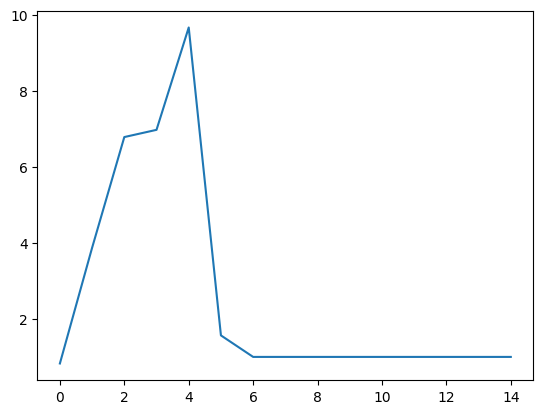

In [296]:
plt.plot( np.arange( len(max_list)), max_list )
plt.show()

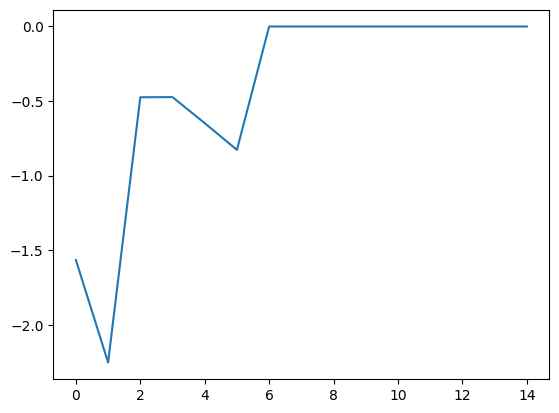

In [297]:
plt.plot( np.arange( len(min_list)), min_list )
plt.show()

# Splitting polished dataset into training and test datasets

In [298]:
#alt approach :
# X = df.drop( "survived" )
# y = df_copy["survived"]

In [299]:
df_target.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [300]:
df.head(  )

,pclass,age,sibsp,parch,fare,class,alone,sex_female,sex_male,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,embarked_C,embarked_Q,embarked_S
0,0.827377,-0.592481,0.432793,-0.473674,-0.502445,-0.827377,0,0,1,0,0,1,0,0,1
1,-1.566107,0.638789,0.432793,-0.473674,0.786845,1.566107,0,1,0,1,0,0,1,0,0
2,0.827377,-0.284663,-0.474545,-0.473674,-0.488854,-0.827377,1,1,0,0,0,1,0,0,1
3,-1.566107,0.407926,0.432793,-0.473674,0.420730,1.566107,0,1,0,0,0,1,0,0,1
4,0.827377,0.407926,-0.474545,-0.473674,-0.486337,-0.827377,1,0,1,0,0,1,0,0,1


In [301]:
from sklearn.model_selection import train_test_split

In [302]:
X_train, X_test, y_train, y_test = train_test_split( df, df_target, test_size=0.2, random_state=42 )

In [303]:
print( len(df_target) )
print( len(y_train) )
print( len(y_test) )

891
712
179


# Fitting a Logistic Regression model on the (X_train, y_train) to predict y_test using the values of X_test

In [304]:
from sklearn.linear_model import LogisticRegression

In [305]:
model = LogisticRegression()

In [306]:
model.fit( X_train, y_train )

LogisticRegression()

In [307]:
y_pred = model.predict( X_test )

# use **accuracy_score** metric to evaluate mismatch between actual labels and the predicted labels

In [308]:
from sklearn.metrics import accuracy_score

In [309]:
print( accuracy_score( y_pred, y_test ) )

0.7988826815642458


# Plot a scatter plot to display difference between the actual labels and the predicted labels

In [310]:
from matplotlib import pyplot as plt

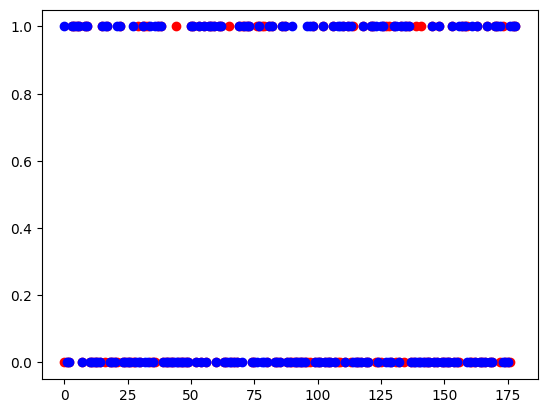

In [311]:
plt.scatter( np.arange( len(y_pred) ), y_pred, color="red" )
plt.scatter( np.arange( len(y_test) ), y_test, color="blue" )
plt.show()

In [312]:
#plt.scatter( np.arange(20), y_pred[:20], color="red" )
#plt.scatter( np.arange(20), y_test[:20], color="blue" )
#plt.show()

In [313]:
#plt.scatter( np.arange(20,40), y_pred[20:40], color="red" )
#plt.scatter( np.arange(20,40), y_test[20:40], color="blue" )
#plt.show()

In [314]:
print( np.array(y_test) )

[1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 1 1
 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1]


In [315]:
mismatch = []
matched_count = 0
mismatched_count = 0

for i in range( len(y_pred) ) :
  val = int(y_pred[i] == np.array(y_test)[i])

  if( val == 0 ) :
    mismatched_count += 1
  else :
    matched_count += 1
  mismatch.append( val )

In [316]:
perc = (matched_count/len(y_pred))*100
formatted_perc = (str(perc))[ : 5 ]

print( formatted_perc )

79.88


# use Histogram for visual description of accuracy_score

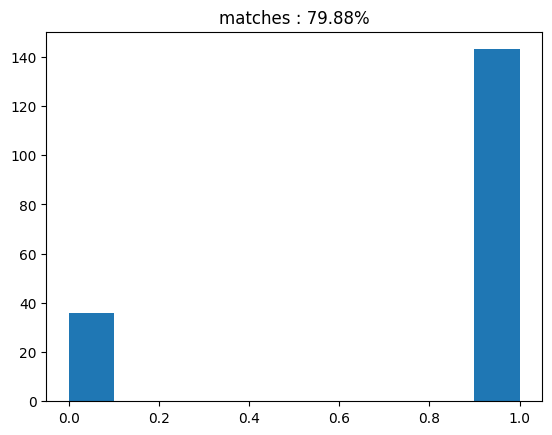

In [317]:
plt.hist( mismatch )
plt.title( "matches : " + formatted_perc + "%" )
plt.show()

In [318]:
#df = scaler_instance.fit_transform(df)
#df = pd.DataFrame( df, columns=df_without_scaling.columns )

# use pie chart for visual description of accuracy_score

In [319]:
categories = ['matched', 'mismatched']
quantities = [matched_count, mismatched_count]

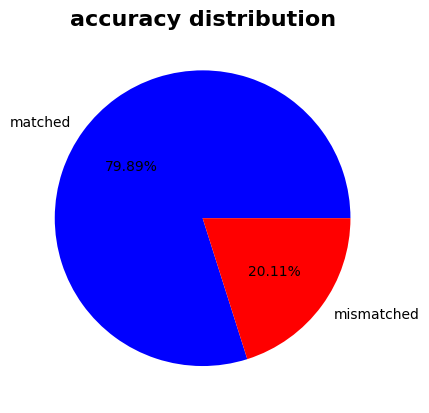

In [320]:

slice_colors = ['blue', 'red']
plt.pie(
    quantities,
    labels=categories,
    autopct='%1.2f%%',
    colors=slice_colors,
)

plt.title('accuracy distribution', fontsize=16, fontweight='bold')
plt.show()